In [15]:
import yaml
from pathlib import Path
import os
from swiss_roll import RUNS_DIR, DATA_DIR, CONF_DIR, PROJECT_ROOT
import pandas as pd
from swiss_roll.scheduling import Schedular
import matplotlib.pyplot as plt
from swiss_roll.config import load_config, load_hyperoptconfig, save_config

In [16]:
guidance_runs_path = RUNS_DIR / 'guidance_models_2'

print('Guidance run path exists:', guidance_runs_path.exists())

metrics_filename = 'eval_metrics.yaml'

Guidance run path exists: True


In [17]:
training_metrics_list = []
validation_metrics_list = []
successful_runs = []
failed_runs = []  
for root, dirs, _ in guidance_runs_path.walk():
    for dir in dirs:  
        metrics_path = root / dir / metrics_filename
        run_id =  int(dir.split("_")[-1])
        
        try:
            with open(metrics_path, 'r') as f:
                metrics = yaml.load(f, yaml.FullLoader)
        except FileNotFoundError:
            failed_runs.append(run_id)
            continue 

        successful_runs.append(run_id)
        metrics['training_metrics']['run_id'] = int(run_id)
        metrics['validation_metrics']['run_id'] = int(run_id)
        training_metrics_list.append(metrics['training_metrics'])
        validation_metrics_list.append(metrics['validation_metrics'])
print("Successful Runs:", len(successful_runs), "Failed Runs:", len(failed_runs))
training_metrics_dataframe = pd.DataFrame.from_records(training_metrics_list)
validation_metrics_dataframe = pd.DataFrame.from_records(validation_metrics_list)

Successful Runs: 378 Failed Runs: 72


In [18]:
guidance_confs_path = CONF_DIR / 'guidance_conf'

print('Guidance run path exists:', guidance_runs_path.exists())

conf_list = []
failed_conf_list = []  
for root, _, files in guidance_confs_path.walk():
    for file in files: 
        conf_path = root / file
        with open(conf_path, 'r') as f:
            conf = yaml.load(f, yaml.FullLoader)
       
        run_id =  int(file.split('.')[0]) 
        conf['run_id'] = run_id
       
        if run_id in successful_runs:
            conf_list.append(conf)
        else: 
            failed_conf_list.append(conf)

conf_dataframe = pd.DataFrame.from_records(conf_list)
failed_conf_dataframe = pd.DataFrame.from_records(failed_conf_list)

Guidance run path exists: True


In [50]:
from optuna.visualization import plot_pareto_front
import numpy as np 


# Return paths of optuna csvs
bayesoptconfs = CONF_DIR / 'bayesopt_conf'
bayesoptdir = RUNS_DIR / 'bayesopt'
figuredir = DATA_DIR / 'figures' / 'bayesopt'
run_results = {} 
for root, dirs, paths in bayesoptconfs.walk():
    for path in paths:
        cfg = load_hyperoptconfig(root / path)
        if cfg.cfg.run.update_embeds and cfg.cfg.run.reg_type in ['mse', 'None']:
            continue 
        run_id = cfg.cfg.run.run_id
        df = pd.read_csv(bayesoptdir / f'trials_{run_id}.csv')
        run_results[run_id] = {} 
        run_results[run_id]['cfg'] = cfg 
        run_results[run_id]['csv'] = df 

for key, value in run_results.items():
    cfg = value['cfg']
    df = value['csv']
    
    run_id = cfg.cfg.run.run_id
    reg_type = cfg.cfg.run.reg_type
    embeds = cfg.cfg.run.update_embeds
    reg_scalar = cfg.cfg.cgd.reg_scale_by
    pareto_front = cfg.pareto 
    title = f'Reg: {reg_type}, GM embeds: {embeds}, RegScale: {reg_scalar}'

    if pareto_front:
        df = df.rename(columns={"values_0": "val_nll", "values_1": "train_nll"})

        # 2) find non-dominated points
        #    a point i is dominated if there's some j with both val_nll_j <= val_nll_i
        #    and train_nll_j <= train_nll_i, with at least one strict
        is_dominated = np.zeros(len(df), dtype=bool)
        for i, (v_i, t_i) in enumerate(df[["val_nll","train_nll"]].values):
            # check if any other point j dominates i
            dominated = ((df["val_nll"] <= v_i) &
                         (df["train_nll"] <= t_i) &
                         ((df["val_nll"] < v_i) | (df["train_nll"] < t_i)))
            # if any True (besides itself), it's dominated
            is_dominated[i] = dominated.any()

        pareto_df = df[~is_dominated]

        # 3) plot
        plt.figure(figsize=(6,6))
        plt.scatter(df["val_nll"], df["train_nll"], alpha=0.3, label="all trials")
        plt.scatter(pareto_df["val_nll"], pareto_df["train_nll"],
                    color="red", label="Pareto front")
        plt.xlabel("Validation NLL")
        plt.ylabel("Training NLL")
        plt.xlim(-2, 20)
        plt.ylim(-2, 20)
        plt.title(title)
        plt.savefig(figuredir / f'pareto_{run_id}.png')
        plt.close()
    else: 
        df = df.rename(columns={"value": "supervised_loss"})
        plt.figure(figsize=(6, 6))
        plt.scatter(df['number'], df['supervised_loss'], alpha=0.3, label="all trials")
        plt.xlabel("Trial ID")
        plt.ylabel("Supervised Loss")
        plt.title(title)
        plt.savefig(figuredir / f'loss_{run_id}')
        plt.close()

In [ ]:
val_conf = validation_metrics_dataframe.merge(conf_dataframe, how='inner', on='run_id')
val_conf = val_conf.sort_values(by='mse')
best_run = val_conf.iloc[0]['run_id']

train_conf = training_metrics_dataframe.merge(conf_dataframe, how='inner', on='run_id')
train_conf = train_conf.sort_values(by='mse')
best_run = training_metrics_dataframe.iloc[0]['run_id'].astype(int)

In [20]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from swiss_roll.utils import load_swissroll, load_model
from swiss_roll.config import load_config, Config
from swiss_roll.guidance import GuidanceModel, GuidanceBlock 

device = 'cpu'
X, Y, Xval, Yval = load_swissroll()
X = X[:, [0, 2]]
Y = Y[:, 0]
Xval = Xval[:, [0, 2]]
Yval = Yval[:, 0]

mse_list = []
mse_val = [] 
run_id = [] 
run_id = 98
model_path = guidance_runs_path / f"run_{run_id:04d}" / "guidance_model.pth"

conf_path = PROJECT_ROOT / "src/swiss_roll/example.yaml"
model_path = PROJECT_ROOT / "src/swiss_roll/example/guidance_model.pth"

cfg = load_config(conf_path)
model_config = {"input_dim": 3}
with torch.no_grad():
    model = load_model(GuidanceModel, model_config, model_path)
    model.eval().to('cpu')

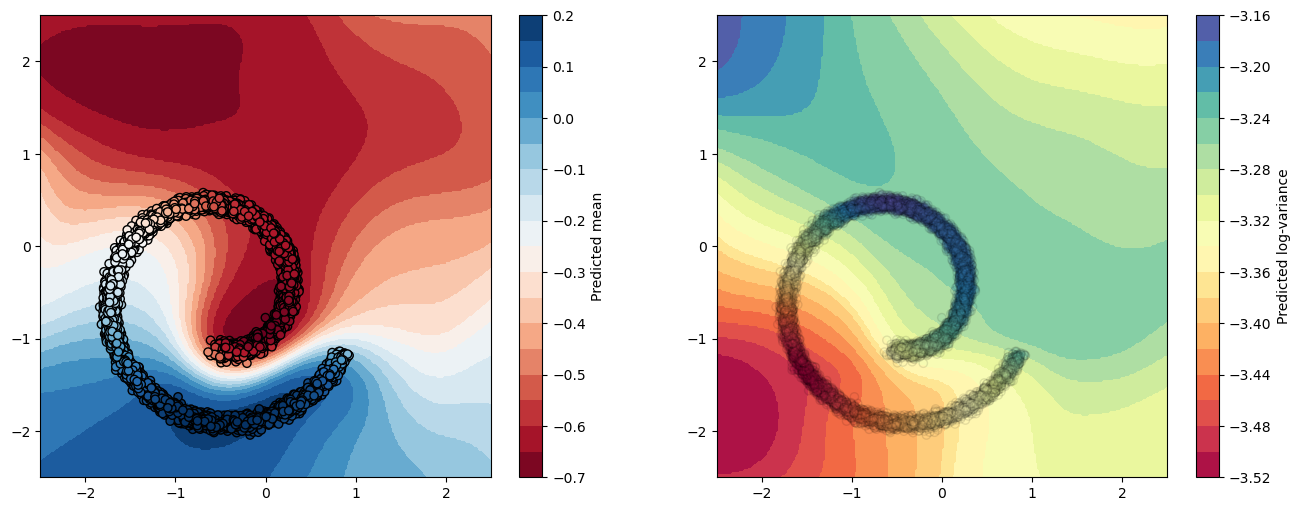

In [21]:
T = 0
expose_time = True 
if expose_time: 
    tens = torch.zeros(size=(X.size()[0], 1))
    X_inp = torch.hstack([X, torch.fill(tens, T)])
    preds, _ = model(X_inp)
else: 
    preds, _ = model(X)
pred_means = preds[:, :1]
pred_logvar = preds[:, 1:]
pred_means = pred_means.to(device).detach().numpy()
pred_logvar = pred_logvar.to(device).detach().numpy()

n = 300
x1_lin = x2_lin = np.linspace(-2.5, 2.5, n)
XX, YY = np.meshgrid(x1_lin, x2_lin)
grid = np.stack([XX.ravel(), YY.ravel()], axis=1)
with torch.no_grad():
    inp = torch.from_numpy(grid).float().to(device)
    if expose_time:
        tens = torch.zeros(size=(inp.size()[0], 1))
        inp = torch.hstack([inp, torch.fill(tens, T)])
    pred, _ = model(inp)
mu = pred[:, :1]
logvar = pred[:, 1:]
ZZ = np.round(logvar.cpu().numpy().reshape(XX.shape), 2)
ZZ_mu = np.round(mu.cpu().numpy().reshape(XX.shape), 2)

fig, ax = plt.subplots(1, 2, figsize=(16,6))
cf = ax[1].contourf(XX, YY, ZZ, levels=20, cmap='Spectral')
cf2 = ax[0].contourf(XX, YY, ZZ_mu, levels=20, cmap='RdBu')
fig.colorbar(cf, ax=ax[1], label='Predicted log-variance') 
fig.colorbar(cf2, ax=ax[0], label='Predicted mean')

idx = torch.randperm(len(X))[: 10_000]
ax[1].scatter(X[idx, 0], X[idx, 1], c=pred_logvar[idx], alpha=0.1, edgecolors='black', cmap='Spectral')
ax[0].scatter(X[idx, 0], X[idx, 1], c=pred_means[idx], alpha=1, edgecolors='black', cmap='RdBu')

In [24]:
from torch.distributions import Normal
from swiss_roll.guidance import get_dataloaders, evaluate_model
lowdataloader, highdataloader = get_dataloaders(128)

evaluate_model(model, highdataloader, cfg, device='cpu')

{'nll': 46.49677540215556,
 'mse': 3.641923878152396,
 'supervised_loss': tensor(46.4983),
 '95%_coverage': 0.0}